# 04 · Calibration + Cost-Based Threshold

The model ranks well but its scores aren't true probabilities (inflated by `scale_pos_weight`). Calibrate them, build a cost matrix, and sweep the threshold to find `t*`, the approve/decline line that minimises expected loss.

In [1]:
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.calibration import CalibratedClassifierCV

sys.path.append("..")
from src import evaluate, model

warnings.filterwarnings("ignore")
FIG_DIR = "../reports/figures"

train = pd.read_parquet("../data/processed/train.parquet")
valid = pd.read_parquet("../data/processed/valid.parquet")

X_train, y_train = train.drop(columns="TARGET"), train["TARGET"]
X_valid, y_valid = valid.drop(columns="TARGET"), valid["TARGET"]

base_rate = y_valid.mean()
print("train:", X_train.shape, " valid:", X_valid.shape)
print("default rate  train: {:.4f}   valid: {:.4f}".format(y_train.mean(), base_rate))

train: (246008, 204)  valid: (61503, 204)
default rate  train: 0.0807   valid: 0.0807


## 1 · The raw model is miscalibrated

Trained with `scale_pos_weight ≈ 11`, the raw scores sit well above the true ~8% default rate.

In [2]:
raw_model = joblib.load("../models/lgbm_model.joblib")
pd_raw = raw_model.predict_proba(X_valid)[:, 1]

print("mean predicted PD (raw): {:.3f}".format(pd_raw.mean()))
print("actual default rate    : {:.3f}".format(base_rate))
print("Brier score (raw)      : {:.4f}".format(evaluate.brier(y_valid, pd_raw)))

mean predicted PD (raw): 0.374
actual default rate    : 0.081
Brier score (raw)      : 0.1742


## 2 · Calibrate — isotonic vs sigmoid

`CalibratedClassifierCV` maps raw scores to honest probabilities inside 5-fold CV. Keep whichever method gives the lower Brier score.

In [3]:
spw = model.pos_weight(y_train)

calibrators = {}
for method in ["sigmoid", "isotonic"]:
    clf = CalibratedClassifierCV(model.make_lgbm(spw), method=method, cv=5)
    clf.fit(X_train, y_train)
    calibrators[method] = clf
    print("fitted", method)

fitted sigmoid


fitted isotonic


In [4]:
scores = {"raw": pd_raw}
scores["sigmoid"] = calibrators["sigmoid"].predict_proba(X_valid)[:, 1]
scores["isotonic"] = calibrators["isotonic"].predict_proba(X_valid)[:, 1]

brier_table = pd.DataFrame({
    "mean_PD": {k: v.mean() for k, v in scores.items()},
    "Brier": {k: evaluate.brier(y_valid, v) for k, v in scores.items()},
})
brier_table.round(4)

,mean_PD,Brier
raw,0.3738,0.1742
sigmoid,0.0807,0.0661
isotonic,0.0809,0.0658


In [5]:
best_method = brier_table.drop(index="raw")["Brier"].idxmin()
pd_cal = scores[best_method]

print("chosen calibration:", best_method)
print("Brier  raw -> {}: {:.4f} -> {:.4f}".format(
    best_method, evaluate.brier(y_valid, pd_raw), evaluate.brier(y_valid, pd_cal)))

chosen calibration: isotonic
Brier  raw -> isotonic: 0.1742 -> 0.0658


### Reliability curve — before vs after

A perfectly calibrated model sits on the diagonal (predicted = observed).

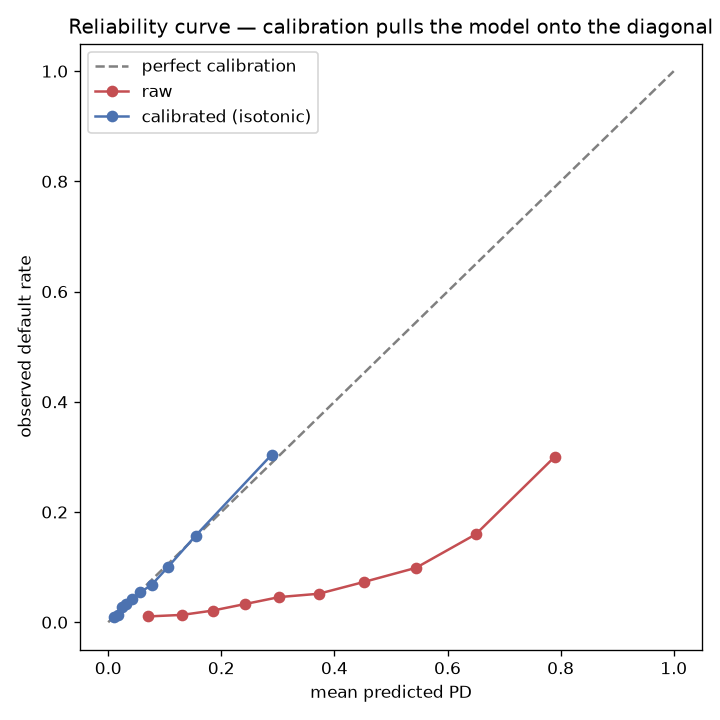

In [6]:
p_raw, o_raw = evaluate.reliability_points(y_valid, pd_raw, n_bins=10)
p_cal, o_cal = evaluate.reliability_points(y_valid, pd_cal, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "--", color="grey", label="perfect calibration")
ax.plot(p_raw, o_raw, marker="o", color="#c44e52", label="raw")
ax.plot(p_cal, o_cal, marker="o", color="#4c72b0", label="calibrated ({})".format(best_method))
ax.set_xlabel("mean predicted PD")
ax.set_ylabel("observed default rate")
ax.set_title("Reliability curve — calibration pulls the model onto the diagonal")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/12_reliability_curve.png", dpi=120)
plt.show()

In [7]:
joblib.dump(calibrators[best_method], "../models/calibrated_model.joblib")
print("saved ../models/calibrated_model.joblib")

saved ../models/calibrated_model.joblib


## 3 · The cost matrix

The two mistakes cost differently, and the cost depends on the loan:

| mistake | meaning | cost |
|---|---|---|
| **False negative** (approve a defaulter) | lose a chunk of the loan | `C_fn = LGD × EAD = 0.60 × AMT_CREDIT` |
| **False positive** (decline a good customer) | lose the margin | `C_fp ≈ AMT_ANNUITY` |

Because `C_fn` ≫ `C_fp`, the best cutoff lands well below 0.5.

In [8]:
amt_credit = X_valid["AMT_CREDIT"]
amt_annuity = X_valid["AMT_ANNUITY"].fillna(X_valid["AMT_ANNUITY"].median())
c_fn, c_fp = evaluate.applicant_costs(amt_credit, amt_annuity, lgd=0.6)

print("median C_fn (missed default): {:,.0f}".format(np.median(c_fn)))
print("median C_fp (false decline) : {:,.0f}".format(np.median(c_fp)))
print("median cost ratio C_fn / C_fp: {:.1f}".format(np.median(c_fn) / np.median(c_fp)))

median C_fn (missed default): 307,238
median C_fp (false decline) : 24,939
median cost ratio C_fn / C_fp: 12.3


## 4 · Threshold sweep — find t*

At each threshold, approve everyone with `PD < t` and total the cost of the mistakes; the minimum is `t*`.

In [9]:
sweep = evaluate.sweep_threshold(y_valid, pd_cal, c_fn, c_fp)
t_star = evaluate.pick_threshold(y_valid, pd_cal, c_fn, c_fp)

i_star = int(np.argmin(sweep["cost"]))
i_half = int(np.argmin(np.abs(sweep["thresholds"] - 0.5)))
cost_star, cost_half = sweep["cost"][i_star], sweep["cost"][i_half]

print("t*                  : {:.2f}".format(t_star))
print("approval @ t*       : {:.1%}".format(sweep["approval_rate"][i_star]))
print("approval @ 0.5      : {:.1%}".format(sweep["approval_rate"][i_half]))
print("expected cost @ t*  : {:,.0f}".format(cost_star))
print("expected cost @ 0.5 : {:,.0f}".format(cost_half))
print("loss cut vs 0.5     : {:.1%}".format(1 - cost_star / cost_half))

t*                  : 0.09
approval @ t*       : 70.2%
approval @ 0.5      : 99.5%
expected cost @ t*  : 943,832,988
expected cost @ 0.5 : 1,618,007,141
loss cut vs 0.5     : 41.7%


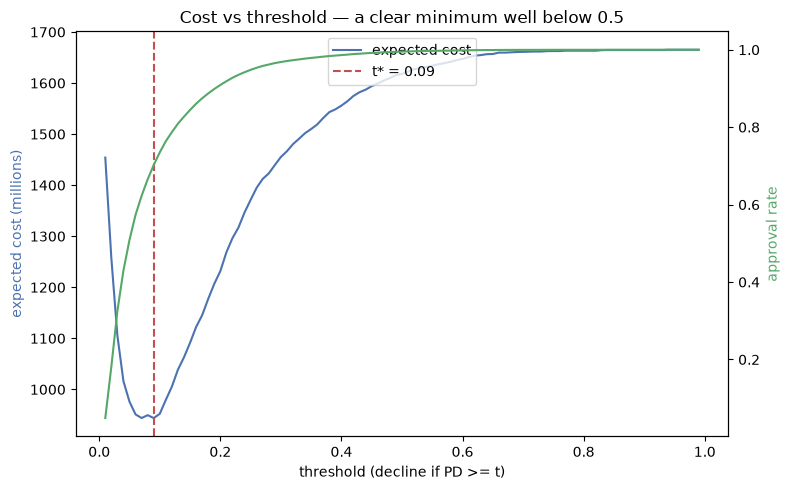

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sweep["thresholds"], sweep["cost"] / 1e6, color="#4c72b0", label="expected cost")
ax.axvline(t_star, color="#c44e52", linestyle="--", label="t* = {:.2f}".format(t_star))
ax.set_xlabel("threshold (decline if PD >= t)")
ax.set_ylabel("expected cost (millions)", color="#4c72b0")
ax.set_title("Cost vs threshold — a clear minimum well below 0.5")

ax2 = ax.twinx()
ax2.plot(sweep["thresholds"], sweep["approval_rate"], color="#55a868", label="approval rate")
ax2.set_ylabel("approval rate", color="#55a868")

ax.legend(loc="upper center")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/13_cost_vs_threshold.png", dpi=120)
plt.show()

## 5 · Confusion matrix at t* (not 0.5)

In [11]:
for t in [0.5, t_star]:
    cm = evaluate.confusion_at(y_valid, pd_cal, t)
    print("threshold {:.2f} | approve {:.1%} |".format(t, (pd_cal < t).mean()), cm)

cm = evaluate.confusion_at(y_valid, pd_cal, t_star)
pd.DataFrame(
    [[cm["TN"], cm["FP"]], [cm["FN"], cm["TP"]]],
    index=["actually repaid", "actually default"],
    columns=["approved", "declined"],
)

threshold 0.50 | approve 99.5% | {'TN': 56424, 'FP': 114, 'FN': 4782, 'TP': 183}
threshold 0.09 | approve 70.2% | {'TN': 41680, 'FP': 14858, 'FN': 1520, 'TP': 3445}


,approved,declined
actually repaid,41680,14858
actually default,1520,3445


## 6 · Sensitivity — does t* move if the costs are wrong?

Re-pick `t*` with the missed-default cost scaled ±50%; a stable `t*` means the decision is robust.

In [12]:
scenarios = {"cost ratio -50%": 0.5, "baseline": 1.0, "cost ratio +50%": 1.5}

sens = {}
for label, k in scenarios.items():
    sens[label] = evaluate.pick_threshold(y_valid, pd_cal, c_fn * k, c_fp)
    print("{:16s} t* = {:.2f}".format(label, sens[label]))

cost ratio -50%  t* = 0.12
baseline         t* = 0.09
cost ratio +50%  t* = 0.04


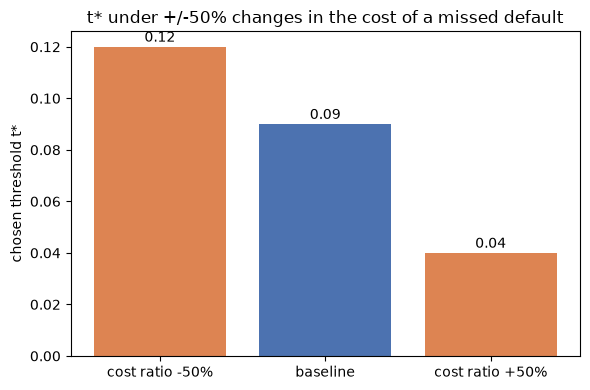

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = list(sens.keys())
ax.bar(labels, [sens[l] for l in labels], color=["#dd8452", "#4c72b0", "#dd8452"])
for i, l in enumerate(labels):
    ax.text(i, sens[l] + 0.002, "{:.2f}".format(sens[l]), ha="center")
ax.set_ylabel("chosen threshold t*")
ax.set_title("t* under +/-50% changes in the cost of a missed default")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/14_threshold_sensitivity.png", dpi=120)
plt.show()

In [14]:
decision = {
    "calibration_method": best_method,
    "brier_raw": float(evaluate.brier(y_valid, pd_raw)),
    "brier_calibrated": float(evaluate.brier(y_valid, pd_cal)),
    "lgd": 0.6,
    "t_star": float(t_star),
    "approval_rate": float(sweep["approval_rate"][i_star]),
    "expected_cost_at_tstar": float(cost_star),
    "expected_cost_at_half": float(cost_half),
    "loss_reduction_vs_half": float(1 - cost_star / cost_half),
    "sensitivity_tstar": {k: float(v) for k, v in sens.items()},
}
with open("../reports/threshold.json", "w") as f:
    json.dump(decision, f, indent=2)
decision

{'calibration_method': 'isotonic',
 'brier_raw': 0.17423538641367975,
 'brier_calibrated': 0.0658112551497079,
 'lgd': 0.6,
 't_star': 0.09,
 'approval_rate': 0.7024047607433783,
 'expected_cost_at_tstar': 943832988.0,
 'expected_cost_at_half': 1618007140.8000002,
 'loss_reduction_vs_half': 0.4166694545406422,
 'sensitivity_tstar': {'cost ratio -50%': 0.12,
  'baseline': 0.09,
  'cost ratio +50%': 0.04}}

## Summary

- Calibration cut the Brier score and pulled the reliability curve onto the diagonal.
- With `C_fn` ≫ `C_fp`, `t*` sits well below 0.5 and stays stable under ±50% cost changes.
- Saved `models/calibrated_model.joblib` and `reports/threshold.json`.